# Imports

In [1]:
import os, sys
import pandas as pd

# Setup path to project root
repo_root = r"C:\Users\charl\OneDrive\Documents\GitHub\NUFFTRR_Poisson"
os.chdir(repo_root)
if repo_root not in sys.path:
    sys.path.append(repo_root)

from Tests.CPU.testing_helpers import (
    run_tests_pipeline,
    render_table2_accuracy,
    render_table2_runtime,
    run_and_plot_errors_vary_m,
    plot_convergence
)

from Tests.CPU.testing_helpers import (
    RADIAL_METHODS,
    run_NM_radial_sweep,
    run_bc_quad_radial_sweep,
    render_NM_radial_accuracy,
    render_NM_radial_runtime,
    render_bc_quad_radial_accuracy,
    render_bc_quad_radial_runtime,
    plot_radial_accuracy_vs_M,
    plot_radial_accuracy_vs_N,
    plot_radial_runtime_vs_M,
    plot_bc_quad_radial_accuracy,
    plot_bc_quad_comparison_vs_M,
    plot_convergence,
)

# Parameters

In [2]:
# ── Edit these freely ────────────────────────────────────────────────────────

N_VALS  = [32, 64, 128, 256, 512]   # angular point counts
M_VALS  = [32, 64, 128, 256, 512]   # radial  point counts
N_FIXED = 128                        # fixed N used in the BC/quad sweep

# Subset of RADIAL_METHODS to run (comment out any you want to skip)
ACTIVE_METHODS = RADIAL_METHODS      # all five by default

MUTE = False   # True = suppress per-case print output

In [3]:
# Run Tests

In [4]:
print("Running N × M sweep...")
df_nm = run_NM_radial_sweep(
    N_values=N_VALS,
    M_values=M_VALS,
    methods=ACTIVE_METHODS,
    bc_choice=1,    # Dirichlet
    quad_rule=1,    # Trapezoidal
    mute=MUTE,
)
print("Done.")

print(f"Running BC × quadrature sweep  (N = {N_FIXED})...")
df_bq = run_bc_quad_radial_sweep(
    N_fixed=N_FIXED,
    M_values=M_VALS,
    methods=ACTIVE_METHODS,
    mute=MUTE,
)
print("Done.")

Running N × M sweep...

── Uniform Radial ──
  N=  32, M=  32 | L2_rel=1.098e-05 | t=0.067s
  N=  32, M=  64 | L2_rel=2.661e-06 | t=0.002s
  N=  32, M= 128 | L2_rel=6.548e-07 | t=0.002s
  N=  32, M= 256 | L2_rel=1.624e-07 | t=0.004s
  N=  32, M= 512 | L2_rel=4.045e-08 | t=0.009s
  N=  64, M=  32 | L2_rel=1.098e-05 | t=0.001s
  N=  64, M=  64 | L2_rel=2.661e-06 | t=0.001s
  N=  64, M= 128 | L2_rel=6.548e-07 | t=0.003s
  N=  64, M= 256 | L2_rel=1.624e-07 | t=0.009s
  N=  64, M= 512 | L2_rel=4.045e-08 | t=0.011s
  N= 128, M=  32 | L2_rel=1.098e-05 | t=0.001s
  N= 128, M=  64 | L2_rel=2.661e-06 | t=0.002s
  N= 128, M= 128 | L2_rel=6.548e-07 | t=0.004s
  N= 128, M= 256 | L2_rel=1.624e-07 | t=0.009s
  N= 128, M= 512 | L2_rel=4.045e-08 | t=0.030s
  N= 256, M=  32 | L2_rel=1.098e-05 | t=0.002s
  N= 256, M=  64 | L2_rel=2.661e-06 | t=0.004s
  N= 256, M= 128 | L2_rel=6.548e-07 | t=0.006s
  N= 256, M= 256 | L2_rel=1.624e-07 | t=0.019s
  N= 256, M= 512 | L2_rel=4.045e-08 | t=0.039s
  N= 512, M=  3

# accuracy 

In [5]:
render_NM_radial_accuracy(df_nm)


render_bc_quad_radial_accuracy(df_bq)


Uniform Radial Accuracy


M,32,64,128,256,512
N,,,,,
32,1.10e-05,2.66e-06,6.55e-07,1.62e-07,4.04e-08
64,1.10e-05,2.66e-06,6.55e-07,1.62e-07,4.04e-08
128,1.10e-05,2.66e-06,6.55e-07,1.62e-07,4.04e-08
256,1.10e-05,2.66e-06,6.55e-07,1.62e-07,4.04e-08
512,1.10e-05,2.66e-06,6.55e-07,1.62e-07,4.04e-08



Nonuniform (sqrt) Accuracy


M,32,64,128,256,512
N,,,,,
32,5.10e-05,1.15e-05,2.71e-06,6.54e-07,1.60e-07
64,5.10e-05,1.15e-05,2.71e-06,6.54e-07,1.60e-07
128,5.10e-05,1.15e-05,2.71e-06,6.54e-07,1.60e-07
256,5.10e-05,1.15e-05,2.71e-06,6.54e-07,1.60e-07
512,5.10e-05,1.15e-05,2.71e-06,6.54e-07,1.60e-07



Nonuniform (rand) Accuracy


M,32,64,128,256,512
N,,,,,
32,9.34e-04,1.18e-03,5.83e-04,1.69e-05,6.67e-05
64,4.73e-03,2.64e-04,8.81e-04,1.77e-04,5.02e-05
128,5.37e-03,2.55e-03,1.25e-03,6.72e-04,5.41e-04
256,8.57e-04,1.61e-03,6.38e-04,3.67e-04,3.70e-04
512,1.84e-03,1.40e-03,9.92e-04,1.45e-04,2.55e-05



BC × Quad Accuracy Accuracy


# runtime

In [6]:
render_NM_radial_runtime(df_nm)


render_bc_quad_radial_runtime(df_bq)


Uniform Radial Runtime (s)


M,32,64,128,256,512
N,,,,,
32,0.0671,0.0023,0.0025,0.0043,0.0092
64,8.77e-04,0.0013,0.0025,0.0094,0.0109
128,0.0011,0.0017,0.0037,0.0086,0.0303
256,0.0016,0.0040,0.0059,0.0194,0.0393
512,0.0080,0.0083,0.0156,0.0338,0.0775



Nonuniform (sqrt) Runtime (s)


M,32,64,128,256,512
N,,,,,
32,0.0022,9.01e-04,0.0023,0.0027,0.0056
64,8.03e-04,0.0011,0.0022,0.0043,0.0079
128,0.0012,0.0019,0.0031,0.0065,0.0157
256,0.0024,0.0042,0.0054,0.0158,0.0352
512,0.0023,0.0055,0.0144,0.0359,0.0777



Nonuniform (rand) Runtime (s)


M,32,64,128,256,512
N,,,,,
32,7.15e-04,9.01e-04,0.0017,0.0041,0.0053
64,7.46e-04,0.0011,0.0020,0.0050,0.0074
128,0.0012,0.0025,0.0036,0.0090,0.0156
256,0.0014,0.0032,0.0056,0.0171,0.0390
512,0.0026,0.0061,0.0139,0.0319,0.0817



BC × Quad Runtime Runtime (s)


# Accuracy Plots

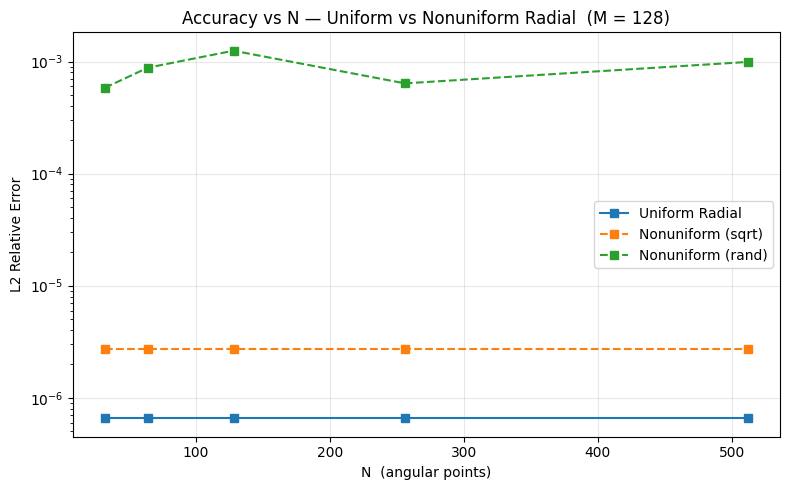

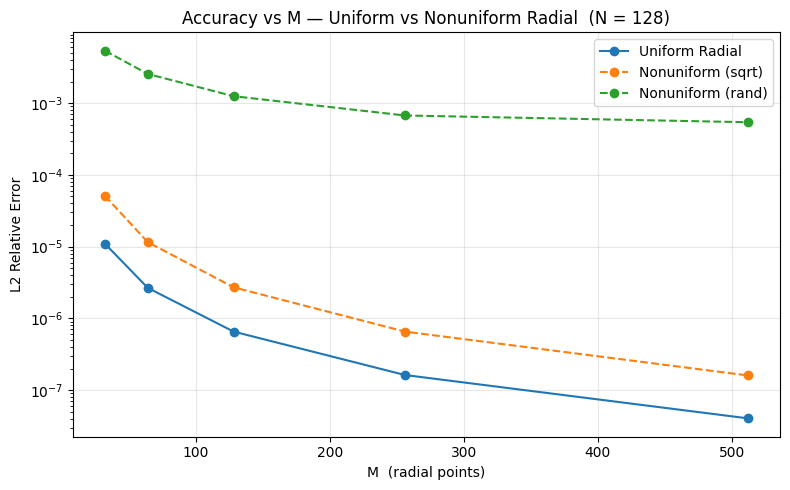

In [7]:
plot_radial_accuracy_vs_N(df_nm, M_fixed=M_VALS[len(M_VALS)//2])

plot_radial_accuracy_vs_M(df_nm, N_fixed=N_VALS[len(N_VALS)//2])


# Runtime Plots

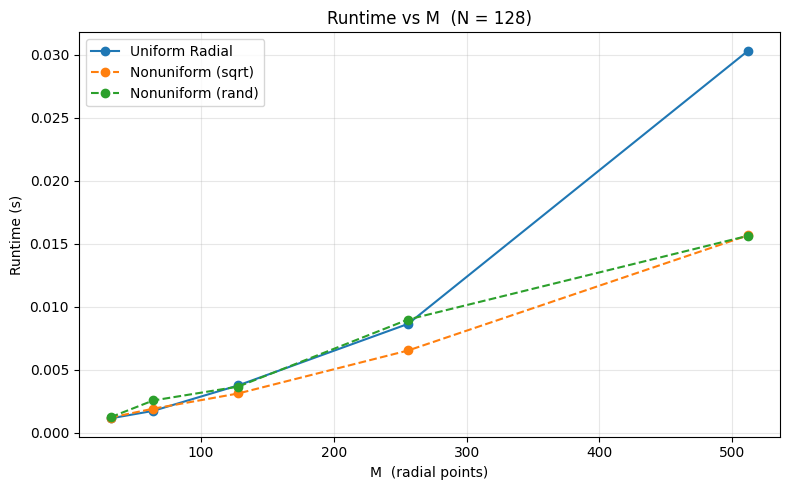

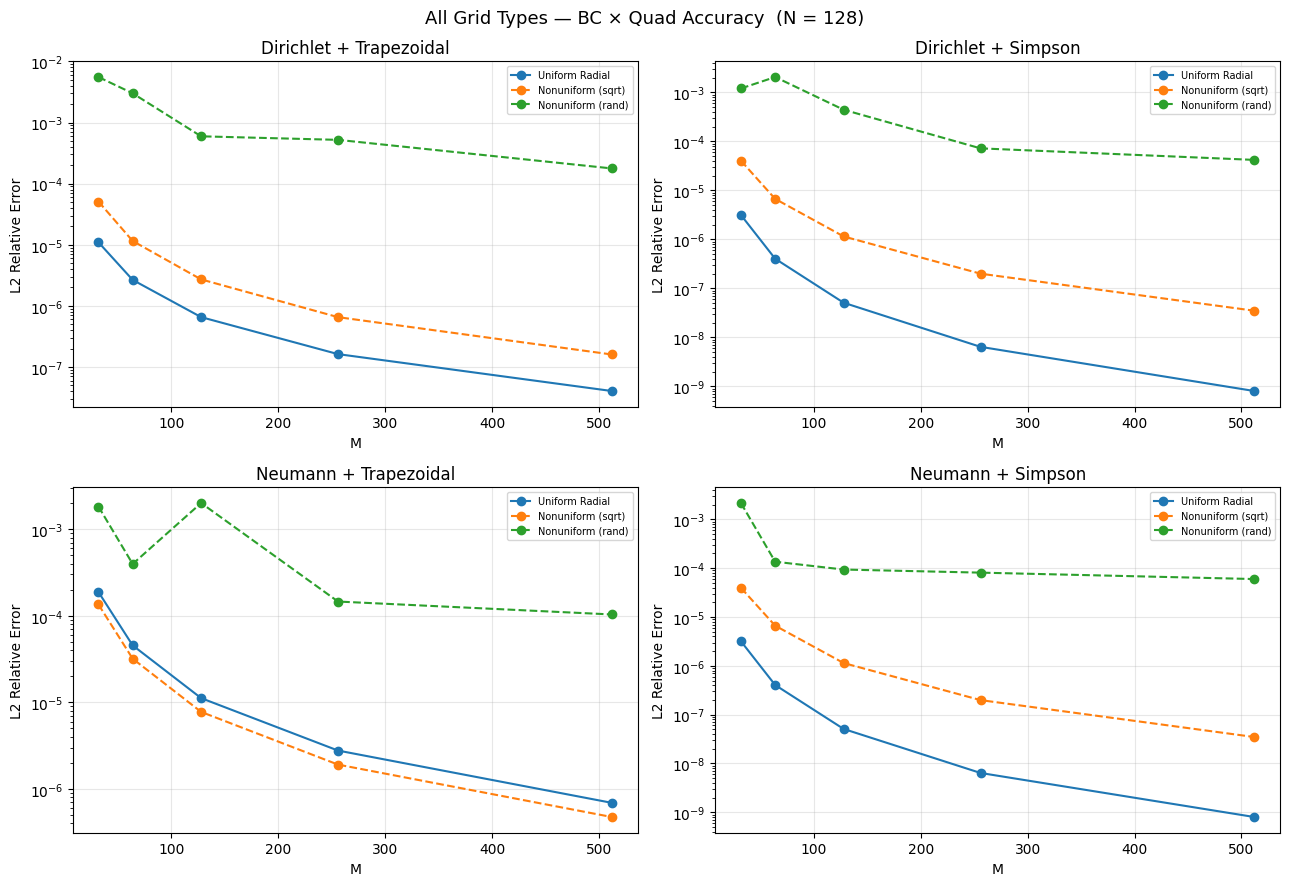

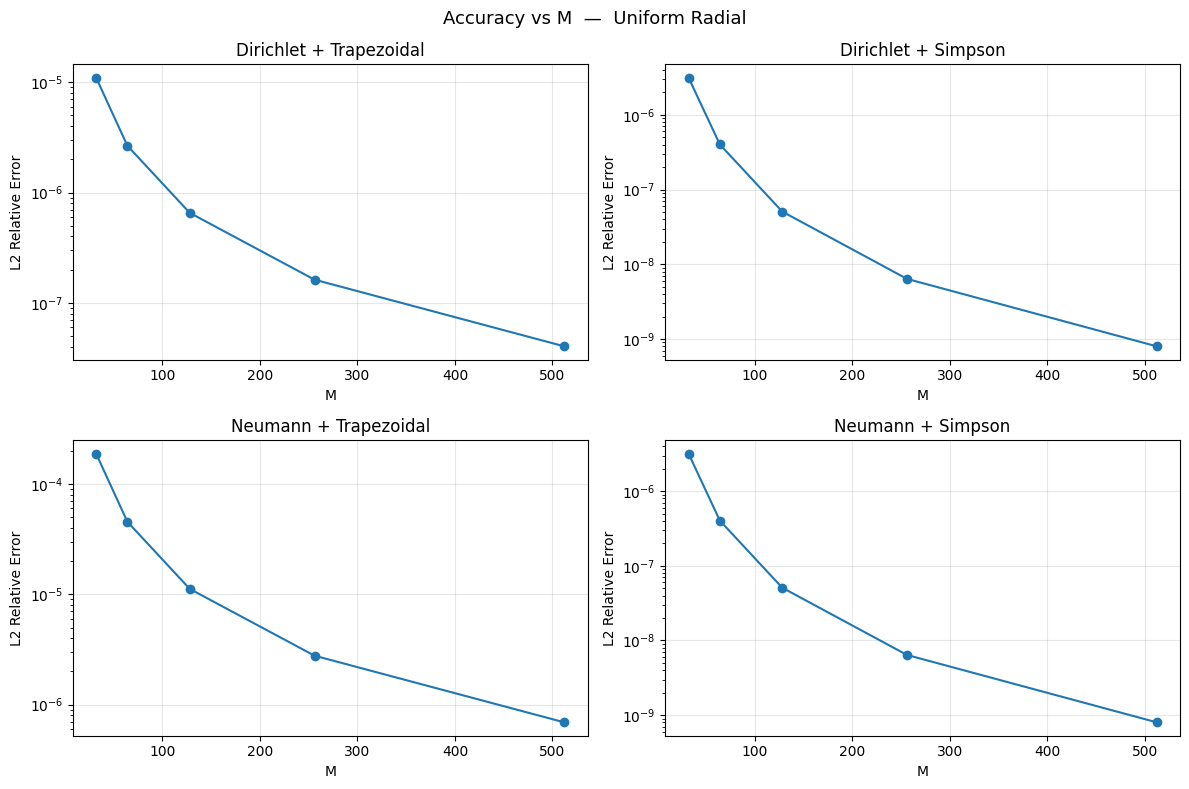

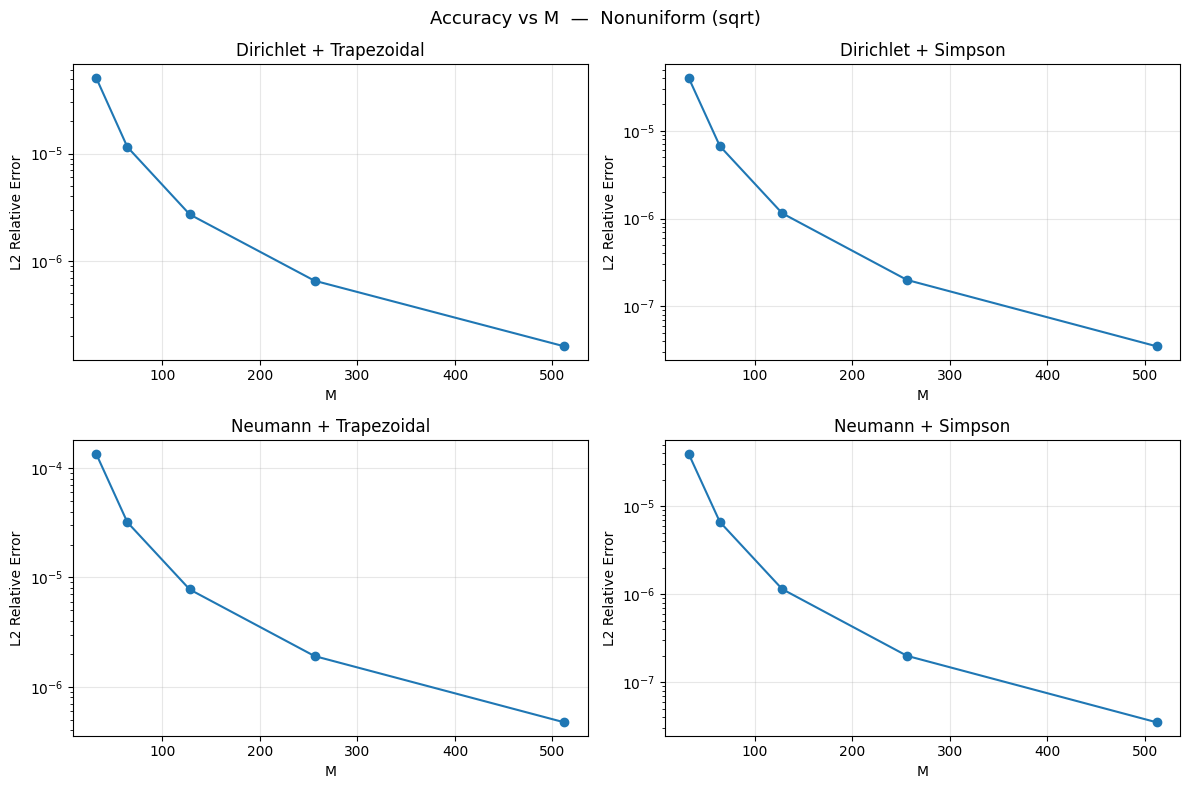

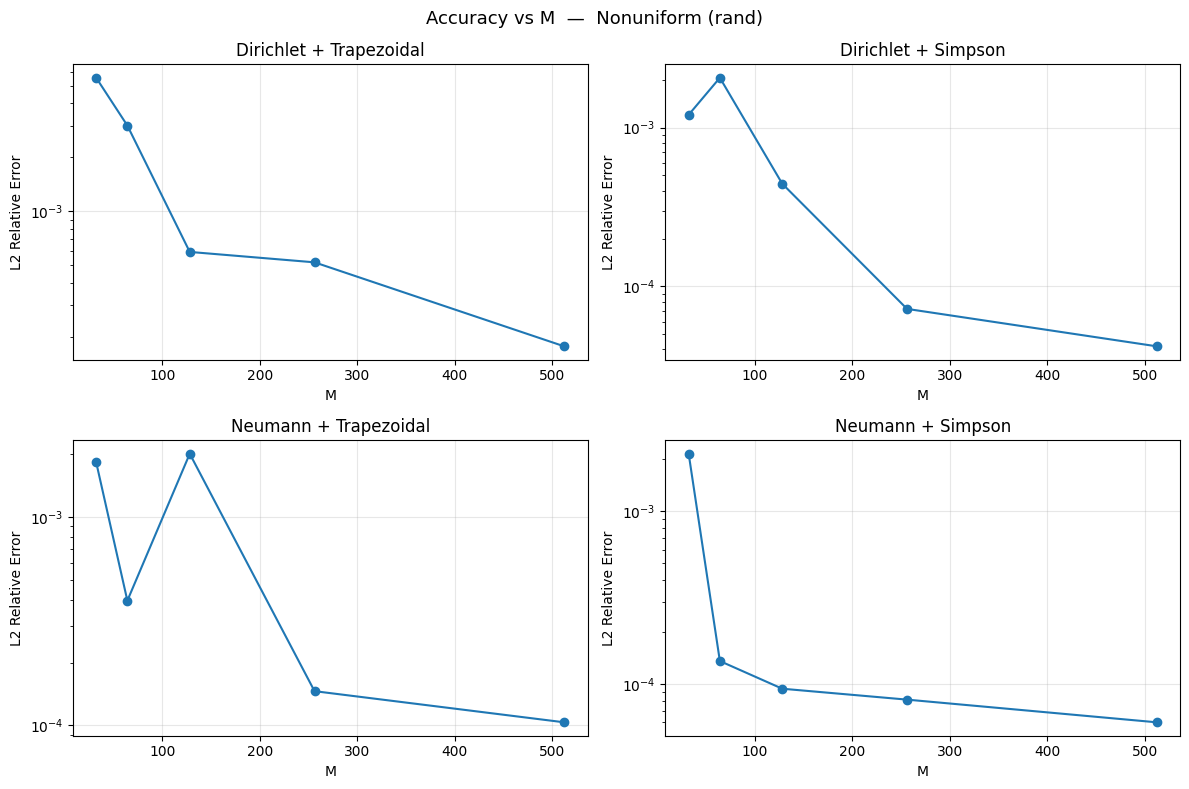

In [8]:
plot_radial_runtime_vs_M(df_nm, N_fixed=N_VALS[len(N_VALS)//2])

plot_bc_quad_comparison_vs_M(df_bq, N_fixed=N_FIXED)


for method in ACTIVE_METHODS:
    plot_bc_quad_radial_accuracy(df_bq, method["label"])